# Project Description:
<b>Mobile carrier Megaline has found out that many of their subscribers use legacy plans. They want to develop a model that would analyze subscribers' behavior and recommend one of Megaline's newer plans: Smart or Ultra. I am developing a model with the highest possible accuracy that will recommend the right plan for the subcribers based on their usage patterns. To do so, I am working with a csv file that contains the following columns: 
calls: Number of calls made by the subscriber.
minutes: Total minutes used.
messages: Total messages sent.
mb_used: Data used in megabytes.
is_ultra: Target variable indicating if the subscriber is on an Ultra plan (1) or Smart plan (0).
</b>

In [1]:
# Importing the libraries
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
# Reading the CSV file
df = pd.read_csv('/datasets/users_behavior.csv')

### Defining Features and Target and Splittin the Data

In [3]:
# Defining features and target
features = df.drop('is_ultra', axis=1)
target = df['is_ultra']

In [4]:
# spliting the data
features_train, features_temp, target_train, target_temp = train_test_split(features,target, test_size=0.4, random_state = 54321, stratify=target)
features_val, features_test, target_val,target_test = train_test_split(features_temp, target_temp, test_size=0.5, random_state=54321, stratify=target_temp)
                                                                            
print(f"Training set size: {len(features_train)}")
print(f"Validation set size: {len(features_val)}")
print(f"Test set size: {len(features_test)}")

Training set size: 1928
Validation set size: 643
Test set size: 643


### Random Forest Classifier

In [5]:
# Model training and evaluation 
best_score = 0
best_est = 0
for est in range(1, 31):
    model = RandomForestClassifier(random_state=54321, n_estimators=est)
    model.fit(features_train, target_train)
    score = model.score(features_val, target_val)
    if score > best_score:
        best_score = score
        best_est = est
print(f"Accuracy of the best model on the validation set (n_estimators = {best_est}): {best_score}")

# Final model training 
final_model = RandomForestClassifier(random_state=54321, n_estimators=best_est)
final_model.fit(features_train, target_train)

#Evaluating the model on the test set
test_score = final_model.score(features_test, target_test)
print(f"Accuracy of the final model on the test set: {test_score}")

# Make predictions on the test set
rt_predictions = final_model.predict(features_test)

# Calculating the Confusion Matrix
rt_conf_matrix = confusion_matrix(target_test, rt_predictions)
print("Confusion Matrix for Random Tree Classifier:\n", rt_conf_matrix)

# Classification Report
print("Classification Report for Random Tree Classifier:\n", classification_report(target_test, rt_predictions))

Accuracy of the best model on the validation set (n_estimators = 4): 0.7947122861586314
Accuracy of the final model on the test set: 0.7744945567651633
Confusion Matrix for Random Tree Classifier:
 [[410  36]
 [109  88]]
Classification Report for Random Tree Classifier:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85       446
           1       0.71      0.45      0.55       197

    accuracy                           0.77       643
   macro avg       0.75      0.68      0.70       643
weighted avg       0.77      0.77      0.76       643



### Decision Tree Classifier

In [6]:
dt_model = DecisionTreeClassifier(random_state=54321)

# Fitting the model on the training data
dt_model.fit(features_train, target_train)

# Evaluate the model on the validation set
dt_val_score = dt_model.score(features_val, target_val)
print(f"Accuracy of Decision Tree Classifier on the validation set: {dt_val_score:.4f}")

# Make predictions on the test set
dt_predictions = dt_model.predict(features_test)

# Calculating the Confusion Matrix
dt_conf_matrix = confusion_matrix(target_test, dt_predictions)
print("Confusion Matrix for Decision Tree Classifier:\n", dt_conf_matrix)

# Classification Report
print("Classification Report for Decision Tree Classifier:\n", classification_report(target_test, dt_predictions))

Accuracy of Decision Tree Classifier on the validation set: 0.7294
Confusion Matrix for Decision Tree Classifier:
 [[360  86]
 [ 92 105]]
Classification Report for Decision Tree Classifier:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       446
           1       0.55      0.53      0.54       197

    accuracy                           0.72       643
   macro avg       0.67      0.67      0.67       643
weighted avg       0.72      0.72      0.72       643



### Dummy Classifier

In [7]:
# Initializing the DummyClassifier to predict the most frequent class
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=54321)

# Fitting the dummy classifier on the training data
dummy_clf.fit(features_train, target_train)

# Making predictions with the Dummy Classifier
dummy_predictions = dummy_clf.predict(features_test)

# Evaluating the DummyClassifier
dummy_accuracy = accuracy_score(target_val, dummy_predictions)
print(f'Accuracy of Dummy Classifier: {dummy_accuracy:.4f}')

# Calculating the confusion matrix
dummy_conf_matrix = confusion_matrix(target_val, dummy_predictions)

# Printing the confusion matrix
print("Confusion Matrix for Dummy Classifier:\n", dummy_conf_matrix)

# Classification Report
print("Classification Report for Dummy Classifier:\n", classification_report(target_test, dt_predictions))

Accuracy of Dummy Classifier: 0.6936
Confusion Matrix for Dummy Classifier:
 [[446   0]
 [197   0]]
Classification Report for Dummy Classifier:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       446
           1       0.55      0.53      0.54       197

    accuracy                           0.72       643
   macro avg       0.67      0.67      0.67       643
weighted avg       0.72      0.72      0.72       643



### Visualisations

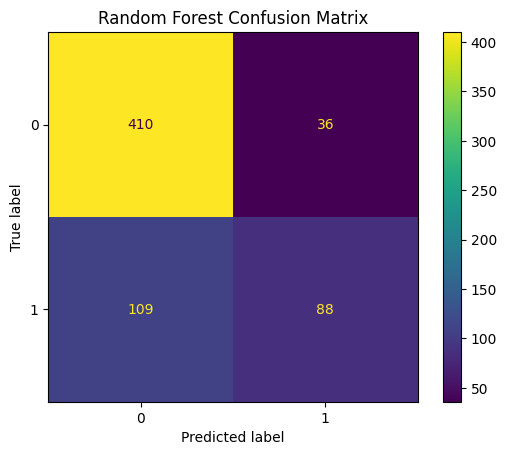

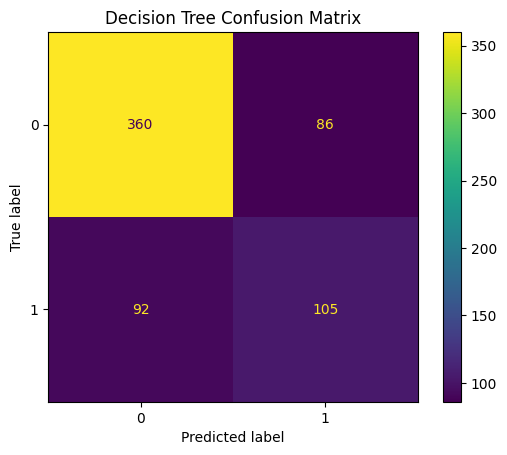

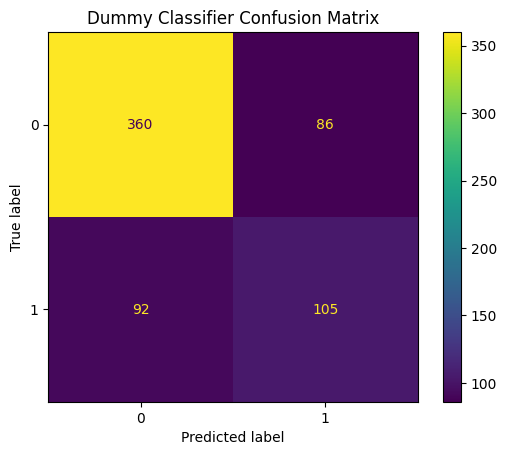

In [8]:
# Random Forest Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=rt_conf_matrix)
disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

# Decision Tree Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=dt_conf_matrix)
disp.plot()
plt.title('Decision Tree Confusion Matrix')
plt.show()

# Dummy Classifier Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=dt_conf_matrix)
disp.plot()
plt.title('Dummy Classifier Confusion Matrix')
plt.show()

# Conclusions
<b>The Dummy Classifier model predicts the most frequent class (Smart Plan) and has lower accuracy showing the the model are learning.The Random Forest Classifier is the best-performing model. It achieved an accuracy of approximately 77.4% on the test set and demonstrated a balanced performance across both classes, as indicated by the confusion matrix and classification report.</b>